In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
820,45,male,33.70,1,no,southwest,7445.91800
32,19,female,28.60,5,no,southwest,4687.79700
792,22,female,23.18,0,no,northeast,2731.91220
418,64,male,39.16,1,no,southeast,14418.28040
1174,29,male,32.11,2,no,northwest,4433.91590
298,31,male,34.39,3,yes,northwest,38746.35510
1318,35,male,39.71,4,no,northeast,19496.71917
334,43,female,35.72,2,no,northeast,19144.57652
989,24,female,20.52,0,yes,northeast,14571.89080
946,42,male,35.80,2,no,southwest,7160.09400


## EDA

In [5]:
df.shape

(1338, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

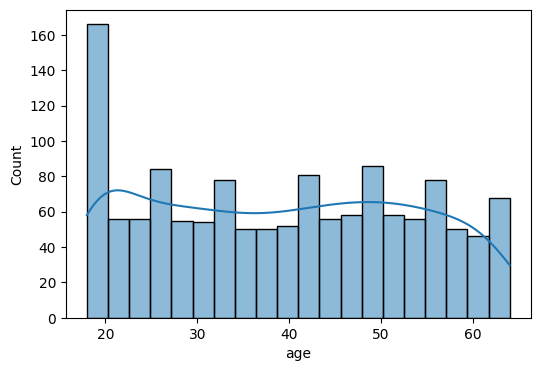

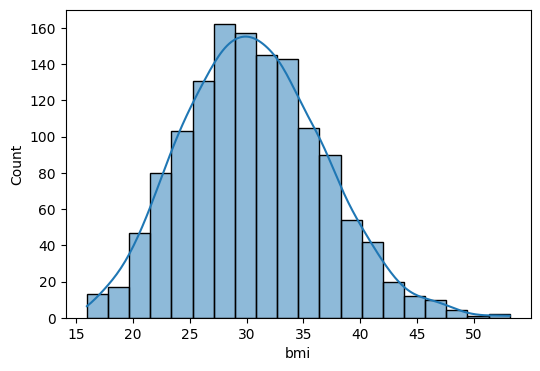

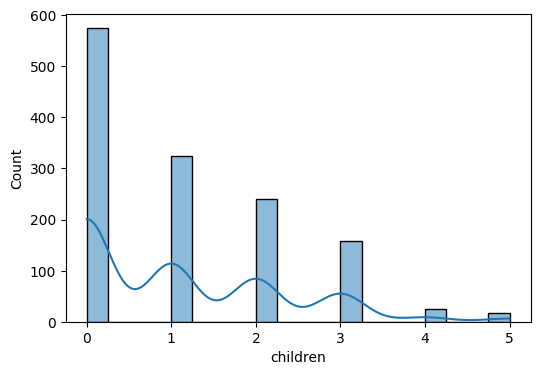

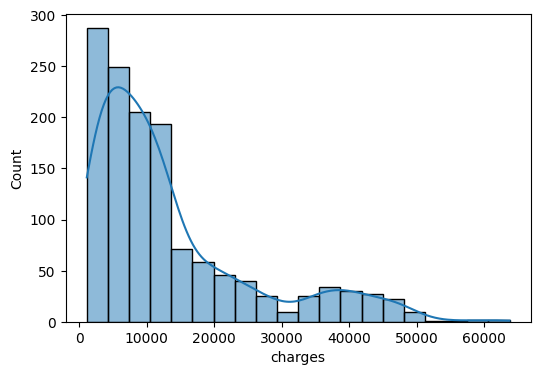

In [9]:
numeric_col=['age','bmi','children','charges']
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<AxesSubplot: xlabel='children', ylabel='count'>

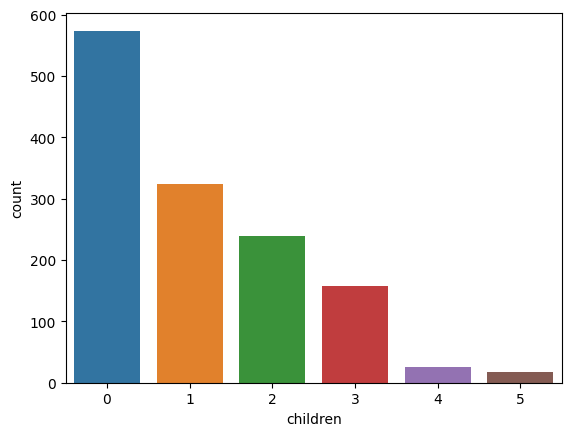

In [10]:
sns.countplot(x=df['children'])

<AxesSubplot: xlabel='sex', ylabel='count'>

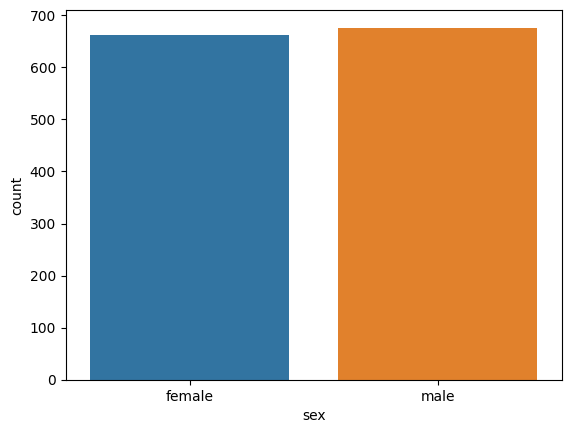

In [11]:
sns.countplot(x=df['sex'])

<AxesSubplot: xlabel='smoker', ylabel='count'>

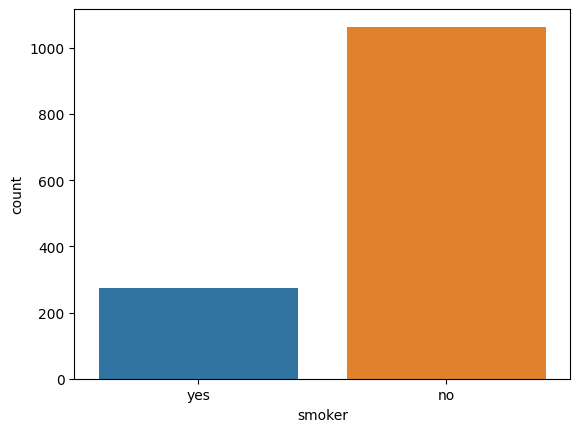

In [12]:
sns.countplot(x=df['smoker'])

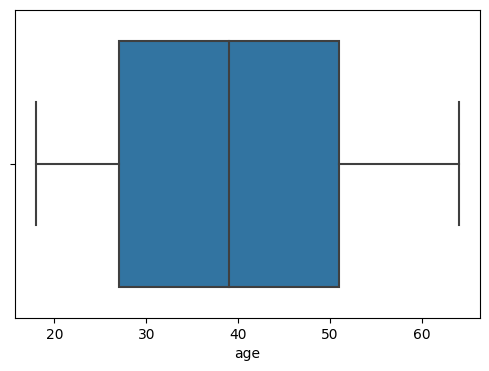

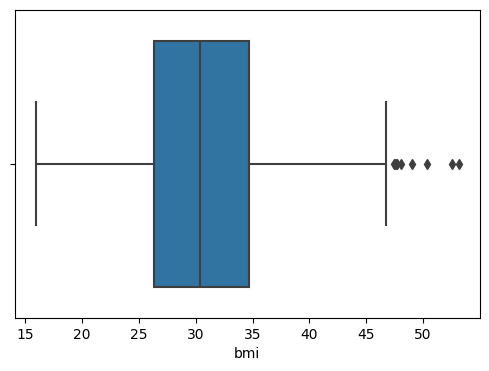

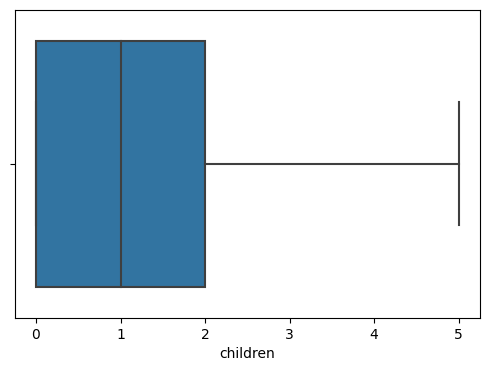

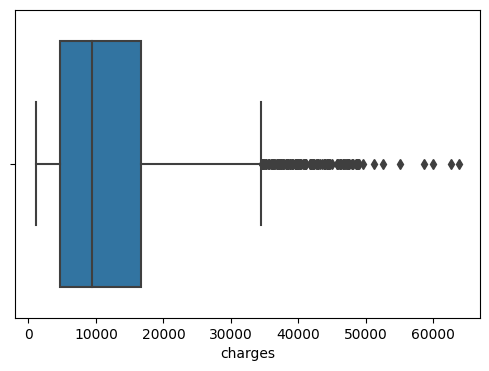

In [13]:
for col in numeric_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<AxesSubplot: >

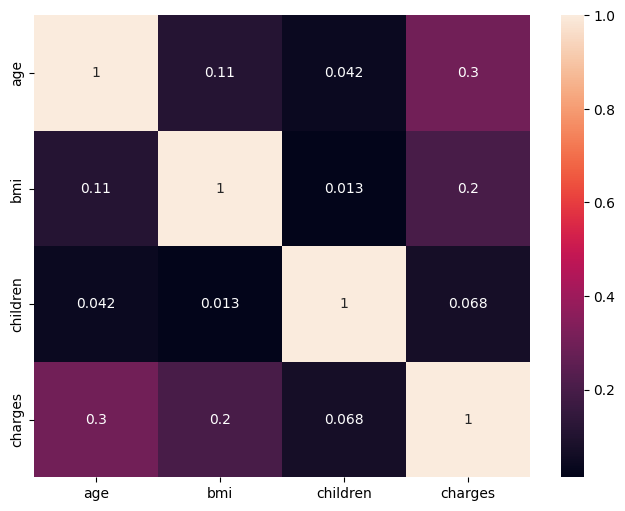

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Cleaning and preprocessing

In [15]:
df_cleaned=df.copy()

In [16]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [17]:
df_cleaned.shape

(1338, 7)

In [18]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(1337, 7)

In [19]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [20]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [21]:
df_cleaned['sex'].value_counts()

male      675
female    662
Name: sex, dtype: int64

## Label encoding

In [22]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [23]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'yes':1,'no':0})
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [24]:
df_cleaned['region'].value_counts()

southeast    364
southwest    325
northwest    324
northeast    324
Name: region, dtype: int64

In [25]:
df_cleaned.rename(columns={
    'sex':'is_femail',
    'smoker':'is_smoker'
},inplace=True)

In [26]:
df_cleaned.head()

,age,is_femail,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [27]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'])

In [28]:
df_cleaned.sample(10)

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
898,18,1,40.260,0,0,1634.57340,0,0,1,0
672,36,0,29.700,0,0,4399.73100,0,0,1,0
1153,35,1,35.815,1,0,5630.45785,0,1,0,0
335,64,0,34.500,0,0,13822.80300,0,0,0,1
1171,43,1,26.700,2,1,22478.60000,0,0,0,1
733,48,1,27.265,1,0,9447.25035,1,0,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
606,27,1,25.175,0,0,3558.62025,1,0,0,0
371,57,1,22.230,0,0,12029.28670,1,0,0,0
656,26,1,42.400,1,0,3410.32400,0,0,0,1


## Feature Engineering

<AxesSubplot: xlabel='bmi', ylabel='Count'>

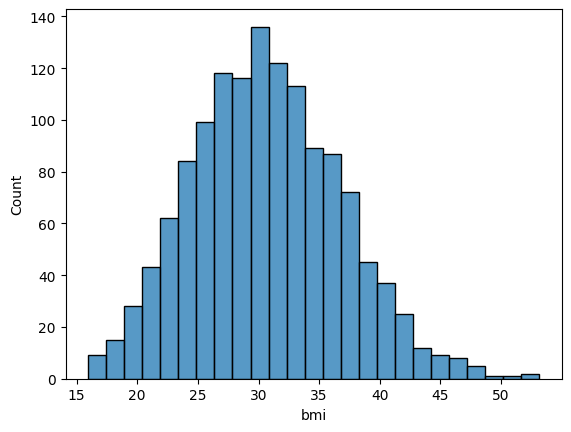

In [29]:
sns.histplot(df.bmi)

In [30]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=["Underweight","Normal","Overweight","Obese"]
    
)

In [31]:
df_cleaned

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,0,1,Overweight
1,18,0,33.770,1,0,1725.55230,0,0,1,0,Obese
2,28,0,33.000,3,0,4449.46200,0,0,1,0,Obese
3,33,0,22.705,0,0,21984.47061,0,1,0,0,Normal
4,32,0,28.880,0,0,3866.85520,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,Obese
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,Obese
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,Obese
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,Overweight


In [32]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'])

In [33]:
df_cleaned

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27.900,0,1,16884.92400,0,0,0,1,0,0,1,0
1,18,0,33.770,1,0,1725.55230,0,0,1,0,0,0,0,1
2,28,0,33.000,3,0,4449.46200,0,0,1,0,0,0,0,1
3,33,0,22.705,0,0,21984.47061,0,1,0,0,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,0,1,0,0,0,0,0,1
1334,18,1,31.920,0,0,2205.98080,1,0,0,0,0,0,0,1
1335,18,1,36.850,0,0,1629.83350,0,0,1,0,0,0,0,1
1336,21,1,25.800,0,0,2007.94500,0,0,0,1,0,0,1,0


## Feature scalling

In [34]:
df_cleaned.columns

Index(['age', 'is_femail', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [35]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']

In [36]:
scaler=StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [37]:
df_cleaned.head()

,age,is_femail,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0,0,1,0,0,1,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,0,0,1,0,0,0,0,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,1,0,0,0,0,1,0


## Feature Selection

In [38]:
df_cleaned.columns

Index(['age', 'is_femail', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [39]:
from scipy.stats import pearsonr
#pearson coorelation
selected_feature=[
    'age', 'is_femail', 'bmi', 'children', 'is_smoker', 
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese']
correlations={
    feature: pearsonr(df_cleaned[feature],df_cleaned['charges'])[0]
    for feature in selected_feature
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['Feature','Pearson_Corelation'])
correlation_df.sort_values(by='Pearson_Corelation',ascending=False)

,Feature,Pearson_Corelation
4,is_smoker,0.787234
0,age,0.298308
2,bmi,0.198401
12,bmi_category_Obese,0.197659
7,region_southeast,0.073578
3,children,0.067389
5,region_northeast,0.005945
6,region_northwest,-0.038695
8,region_southwest,-0.043637
9,bmi_category_Underweight,-0.048225


In [40]:

cat_features = [
    'is_femail', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

In [41]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_femail,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [42]:
final_df = df_cleaned[['age', 'is_femail', 'bmi', 'children', 'is_smoker', 'charges','region_southeast','bmi_category_Obese']]

In [43]:
final_df

,age,is_femail,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,0,0
1,-1.511647,0,0.509422,-0.079442,0,1725.55230,1,1
2,-0.799350,0,0.383155,1.580143,0,4449.46200,1,1
3,-0.443201,0,-1.305052,-0.909234,0,21984.47061,0,0
4,-0.514431,0,-0.292456,-0.909234,0,3866.85520,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,0.050269,1.580143,0,10600.54830,0,1
1334,-1.511647,1,0.206053,-0.909234,0,2205.98080,0,1
1335,-1.511647,1,1.014490,-0.909234,0,1629.83350,1,1
1336,-1.297958,1,-0.797524,-0.909234,0,2007.94500,0,0
